### Imports

In [1]:
# train.csv
! gdown 19gyTA8S9wXPlxkyU0mZ_raJO62ny-vpo

# test.csv
! gdown 1NqChJSt70NvgInNvYEyh2GTsBfpXUNuj

# Download dataset
! gdown 1wi_kAVETQHQyGA-thBhP7VY1L2jD5quI

# Unzip
! tar -xzf "CrisisMMD_v2.0.tar.gz"

Downloading...
From: https://drive.google.com/uc?id=19gyTA8S9wXPlxkyU0mZ_raJO62ny-vpo
To: /content/train.csv
100% 988k/988k [00:00<00:00, 140MB/s]
Downloading...
From: https://drive.google.com/uc?id=1NqChJSt70NvgInNvYEyh2GTsBfpXUNuj
To: /content/test.csv
100% 421k/421k [00:00<00:00, 127MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1wi_kAVETQHQyGA-thBhP7VY1L2jD5quI
From (redirected): https://drive.google.com/uc?id=1wi_kAVETQHQyGA-thBhP7VY1L2jD5quI&confirm=t&uuid=15c8333e-d8f8-4641-a5dd-c443c35e3f80
To: /content/CrisisMMD_v2.0.tar.gz
100% 1.90G/1.90G [00:07<00:00, 246MB/s]


In [2]:
from google.colab import drive
from pathlib import Path
import os, sys

drive.mount('/content/drive')

DRIVE_CKPT    = Path('/content/drive/MyDrive/checkpoints')
VISION_CKPT   = DRIVE_CKPT / 'vision_brain.pth'
DRIVE_CKPT.mkdir(parents=True, exist_ok=True)

if not os.path.exists('/content/Data-Science-Project'):
    !git clone -b feat/data-pipeline-improvements --single-branch https://github.com/brian-w-zhang/Data-Science-Project.git

# Go to the repo root (adjust path if needed)
%cd /content/Data-Science-Project

# Make sure repo root is on sys.path
repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.append(repo_root)

print("Using repo_root:", repo_root)
print('vision checkpoint:', VISION_CKPT)

Mounted at /content/drive
Cloning into 'Data-Science-Project'...
remote: Enumerating objects: 188, done.
remote: Counting objects: 100% (182/182), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 188 (delta 97), reused 125 (delta 49), pack-reused 6 (from 1)
Receiving objects: 100% (188/188), 7.40 MiB | 19.18 MiB/s, done.
Resolving deltas: 100% (98/98), done.
/content/Data-Science-Project
Using repo_root: /content/Data-Science-Project
vision checkpoint: /content/drive/MyDrive/checkpoints/vision_brain.pth


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay,
    classification_report,
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from data.crisismmd import (
    load_crisismmd_annotations,
    CrisisVisionDataset,
    make_train_transforms,
    make_eval_transforms,
)
from models.vision_branch import build_resnet_classifier, VisionDatasetWrapper
from training.utils import train_one_epoch, evaluate, seed_everything

### Load CrisisMMD dataset

In [4]:
seed_everything(42)

# Root directory where you extracted CrisisMMD_v2.0
root = "/content/CrisisMMD_v2.0"  # adjust if needed

# Load and merge all annotation .tsv files
combined = load_crisismmd_annotations(root)

# Keep the columns we care about
dataset_df = combined[["tweet_id", "image_id", "text_info", "image_info", "tweet_text", "image_path"]]

# Split into train / validation
train_df, val_df = train_test_split(dataset_df, test_size=0.2, random_state=42)

# Transforms
train_tf = make_train_transforms()
val_tf   = make_eval_transforms()

# Base datasets: each returns (image_tensor, label)
base_train_ds = CrisisVisionDataset(train_df, root_dir=root, transform=train_tf)
base_val_ds   = CrisisVisionDataset(val_df,   root_dir=root, transform=val_tf)

# Wrapped datasets: each returns ((image_tensor,), label)
train_ds = VisionDatasetWrapper(base_train_ds)
val_ds   = VisionDatasetWrapper(base_val_ds)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)

# Quick sanity check
images_batch, labels_batch = next(iter(train_loader))
print("Batch images shape:", images_batch[0].shape)  # images_batch is a tuple with one tensor
print("Batch labels shape:", labels_batch.shape)

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])


### Build model, criterion and optimizer

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = build_resnet_classifier(num_classes=2, pretrained=True).to(device)

# Freeze all, then unfreeze layer3, layer4, and fc
for p in model.parameters():
    p.requires_grad = False
for p in model.layer3.parameters():
    p.requires_grad = True
for p in model.layer4.parameters():
    p.requires_grad = True
for p in model.fc.parameters():
    p.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    {'params': model.layer3.parameters(), 'lr': 1e-5},  # lower LR for earlier layer
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(),     'lr': 1e-3},
])

EPOCHS   = 15
PATIENCE = 3

# StepLR: decay all LRs by 0.5 every 3 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

train_loss_hist, train_acc_hist = [], []
val_loss_hist,   val_acc_hist   = [], []

best_val_f1      = 0.0
patience_counter = 0
best_epoch       = 0

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 132MB/s]


### Train the model

In [6]:
os.makedirs('../checkpoints', exist_ok=True)
print("Starting ResNet training...")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )
    scheduler.step()  # epoch-level step

    val_loss, val_acc, val_preds, val_true, val_probs = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    val_f1 = f1_score(val_true, val_preds, average='macro')

    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), str(VISION_CKPT))
        print(f'  ✓ New best saved to Drive (macro F1={val_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  No improvement. Patience: {patience_counter}/{PATIENCE}')
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1}. Best was epoch {best_epoch}.')
            break

print(f'\nDone. Best val macro F1: {best_val_f1:.4f} at epoch {best_epoch}')

Starting ResNet training...

Epoch 1/15


train_loss=0.4356, train_acc=0.7948, val_loss=0.3898, val_acc=0.8206
  ✓ New best saved to Drive (macro F1=0.8203)

Epoch 2/15


train_loss=0.3269, train_acc=0.8541, val_loss=0.4027, val_acc=0.8203
  No improvement. Patience: 1/3

Epoch 3/15


train_loss=0.2519, train_acc=0.8937, val_loss=0.6318, val_acc=0.7556
  No improvement. Patience: 2/3

Epoch 4/15


train_loss=0.1607, train_acc=0.9361, val_loss=0.4631, val_acc=0.8242
  ✓ New best saved to Drive (macro F1=0.8238)

Epoch 5/15


train_loss=0.1184, train_acc=0.9500, val_loss=0.5627, val_acc=0.8302
  ✓ New best saved to Drive (macro F1=0.8302)

Epoch 6/15


train_loss=0.1029, train_acc=0.9587, val_loss=0.6291, val_acc=0.8242
  No improvement. Patience: 1/3

Epoch 7/15


train_loss=0.0820, train_acc=0.9665, val_loss=0.6825, val_acc=0.8283
  No improvement. Patience: 2/3

Epoch 8/15


train_loss=0.0662, train_acc=0.9735, val_loss=0.6883, val_acc=0.8269
  No improvement. Patience: 3/3

Early stopping at epoch 8. Best was epoch 5.

Done. Best val macro F1: 0.8302 at epoch 5


### Plot train/val curves

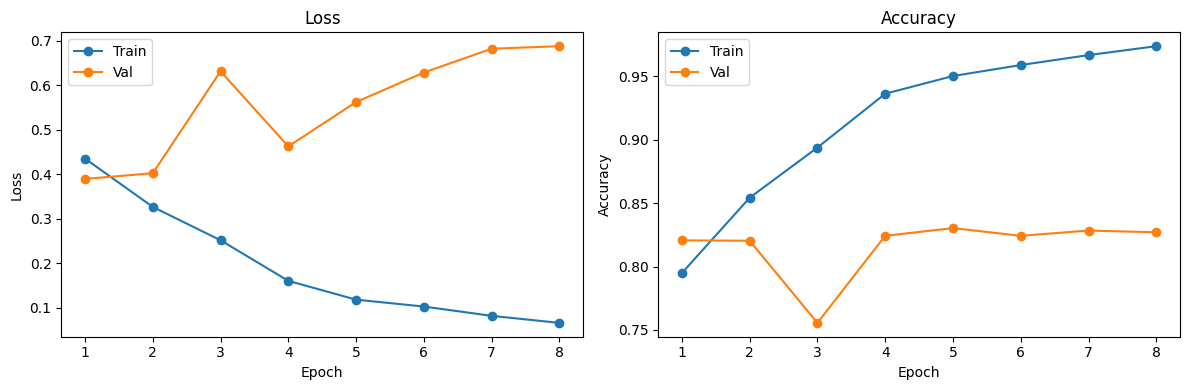

In [7]:
epochs_ran = np.arange(1, len(train_loss_hist) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(epochs_ran, train_loss_hist, marker='o', label='Train')
ax[0].plot(epochs_ran, val_loss_hist,   marker='o', label='Val')
ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(epochs_ran, train_acc_hist, marker='o', label='Train')
ax[1].plot(epochs_ran, val_acc_hist,   marker='o', label='Val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

### Evaluation on best checkpoint


--- VISION MODEL (RESNET) VALIDATION RESULTS ---
Val Accuracy:    83.02%
Val F1 (binary): 0.8292
Val F1 (macro):  0.8302
Val ROC-AUC:     0.9059
              precision    recall  f1-score   support

    Safe (0)       0.79      0.88      0.83      1719
Disaster (1)       0.88      0.79      0.83      1898

    accuracy                           0.83      3617
   macro avg       0.83      0.83      0.83      3617
weighted avg       0.84      0.83      0.83      3617



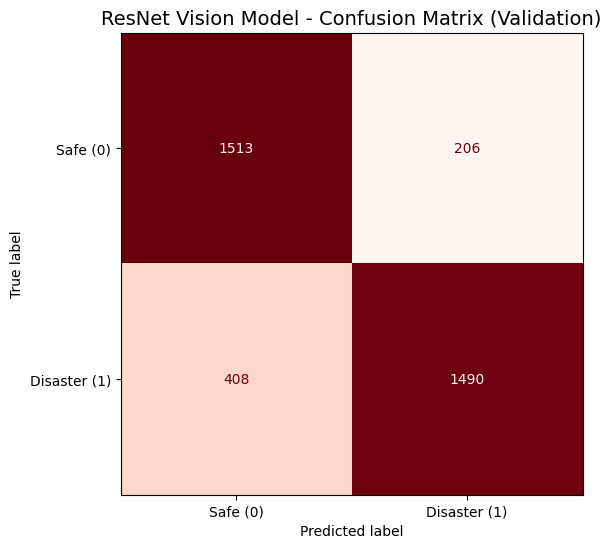

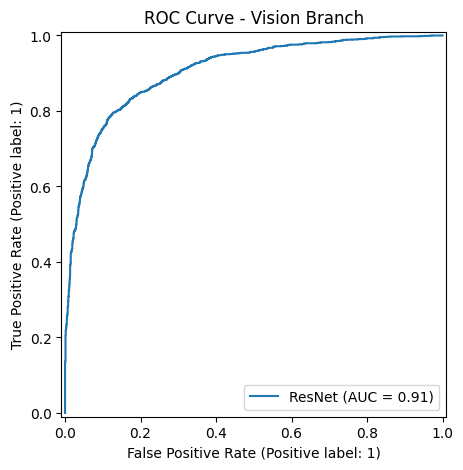

In [8]:
model.load_state_dict(torch.load(str(VISION_CKPT), map_location=device))

val_loss, val_acc, val_preds, val_true, val_probs = evaluate(
    model=model, loader=val_loader, criterion=criterion, device=device,
)

val_f1_macro  = f1_score(val_true, val_preds, average='macro')
val_f1_binary = f1_score(val_true, val_preds, average='binary')
val_roc_auc   = roc_auc_score(val_true, val_probs[:, 1])

print('\n--- VISION MODEL (RESNET) VALIDATION RESULTS ---')
print(f'Val Accuracy:    {val_acc * 100:.2f}%')
print(f'Val F1 (binary): {val_f1_binary:.4f}')
print(f'Val F1 (macro):  {val_f1_macro:.4f}')
print(f'Val ROC-AUC:     {val_roc_auc:.4f}')
print(classification_report(val_true, val_preds, target_names=['Safe (0)', 'Disaster (1)']))

cm = confusion_matrix(val_true, val_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Safe (0)', 'Disaster (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Reds', ax=ax, colorbar=False)
plt.title('ResNet Vision Model - Confusion Matrix (Validation)', fontsize=14)
plt.grid(False)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(val_true, val_probs[:, 1], ax=ax, name='ResNet')
ax.set_title('ROC Curve - Vision Branch')
plt.show()